# Magnetometer Calibration Notebook

This notebook walks you through loading raw magnetometer data from the OpenLog Artemis, visualizing it, and computing hard iron calibration offsets.

**Before running:** make sure your `magcaldata.csv` file is in the `ola_data/` folder at the repo root.

## Step 1 — Load the data

In [152]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

path = './magcaldata.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 4390 samples


## Step 2 — Plot the raw magnetometer data

A well-sampled, uncalibrated magnetometer traces an **off-center ellipsoid** in 3D space. The offset from the origin is caused by hard iron distortion (permanent magnetic fields near the sensor). Your goal is to find and remove that offset so the data forms a sphere centered at the origin.

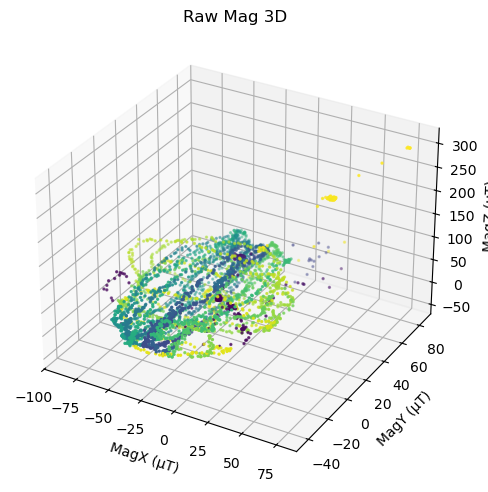

In [153]:
# 3D scatter — raw data
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx, my, mz, s=2, c=t, cmap='viridis')
ax3d.set_title('Raw Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

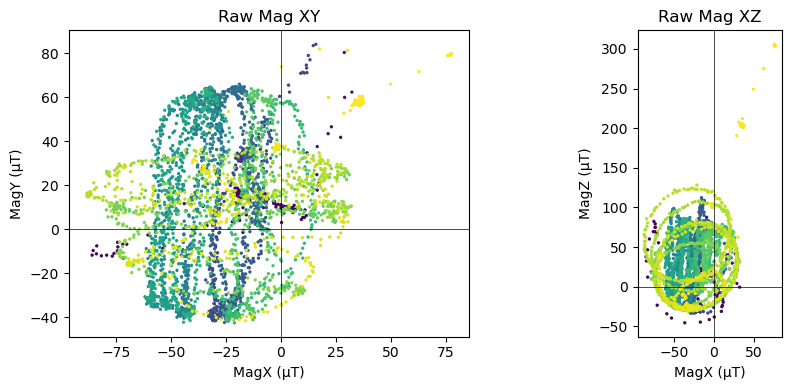

In [154]:
# XY and XZ projections — raw data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx, my, s=2, c=t, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Raw Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx, mz, s=2, c=t, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Raw Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 3 — Compute hard iron offsets

The hard iron offset on each axis is the midpoint between the maximum and minimum values measured:

$$\text{offset}_x = \frac{\max(X) + \min(X)}{2}$$

Repeat for Y and Z. Fill in the cells below.

In [155]:
# TODO: compute the min and max for each axis
mx_min = min(mx)
mx_max = max(mx)
my_min = min(my)
my_max = max(my)
mz_min = min(mz)
mz_max = max(mz)

print(f'MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')

MagX range: -88.20 to 77.40 µT
MagY range: -42.60 to 84.00 µT
MagZ range: -45.60 to 305.85 µT


In [156]:
## Step 3b — Outlier trimming
# A single pass near a magnetic object (laptop, speaker, battery pack) can
# inflate one axis max and corrupt the midpoint estimate. We reject samples
# whose total field magnitude exceeds b_thresh before computing offsets.
# Adjust b_thresh if too many samples are dropped or offsets still look wrong.

b_thresh = 150.0   # µT

B = [(x**2 + y**2 + z**2)**0.5 for x, y, z in zip(mx, my, mz)]
mask = [b <= b_thresh for b in B]

mx_c = [v for v, m in zip(mx, mask) if m]
my_c = [v for v, m in zip(my, mask) if m]
mz_c = [v for v, m in zip(mz, mask) if m]

n_removed = len(mx) - len(mx_c)
print(f'Threshold: {b_thresh} µT  —  removed {n_removed}/{len(mx)} samples '
      f'({100*n_removed/len(mx):.1f}%)')

# Overwrite min/max so the offset cell below uses cleaned values
mx_min, mx_max = min(mx_c), max(mx_c)
my_min, my_max = min(my_c), max(my_c)
mz_min, mz_max = min(mz_c), max(mz_c)

print(f'Clean MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'Clean MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'Clean MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')

Threshold: 150.0 µT  —  removed 83/4390 samples (1.9%)
Clean MagX range: -88.20 to 32.25 µT
Clean MagY range: -42.60 to 84.00 µT
Clean MagZ range: -45.60 to 128.10 µT


In [157]:
# TODO: compute the hard iron offsets (midpoint of each axis range)
offset_x = (mx_min+mx_max)/2
offset_y = (my_min+my_max)/2
offset_z = (mz_min+mz_max)/2

print(f'Hard iron offsets: X={offset_x:.3f}, Y={offset_y:.3f}, Z={offset_z:.3f} µT')

Hard iron offsets: X=-27.975, Y=20.700, Z=41.250 µT


## Step 4 — Apply the calibration

Subtract the offsets from the raw measurements to center the data at the origin.

In [158]:
# TODO: apply the offsets to produce calibrated mag vectors
mx_cal = np.array(mx) - offset_x
my_cal = np.array(my) - offset_y
mz_cal = np.array(mz) - offset_z

### Check the offsets are the right way - mean should be near-ish to zero after calibration for each axis, or at least closer than pre-calibration

In [159]:
print(f'{"Axis":<6} {"Raw mean (µT)":>15} {"Cal mean (µT)":>15}')
print('-' * 38)
for label, raw, cal in [('X', mx, mx_cal), ('Y', my, my_cal), ('Z', mz, mz_cal)]:
    print(f'{label:<6} {np.mean(raw):>15.3f} {np.mean(cal):>15.3f}')

Axis     Raw mean (µT)   Cal mean (µT)
--------------------------------------
X              -23.422           4.553
Y               14.607          -6.093
Z               41.727           0.477


## Step 5 — Plot the calibrated data

After calibration the 3D scatter should look like a sphere centered near the origin. If it still looks like an ellipsoid (stretched in one direction), you may need soft iron correction too.

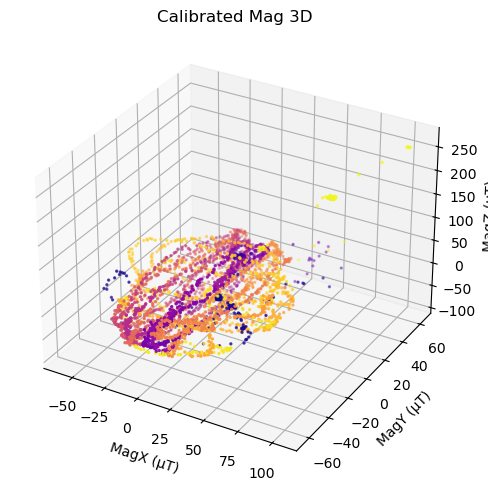

In [160]:
# 3D scatter — calibrated
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax3d.set_title('Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

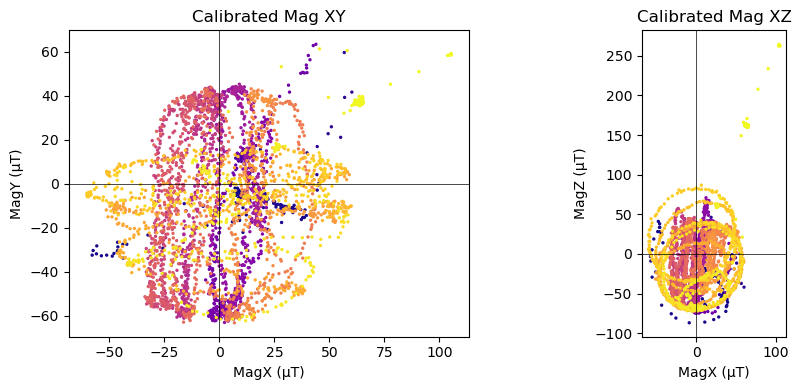

In [161]:
# XY and XZ projections — calibrated
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
axes[0].set_aspect('equal')
axes[0].set_title('Calibrated Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
axes[1].set_aspect('equal')
axes[1].set_title('Calibrated Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 6 — Record your calibration values

Write down your hard iron offsets — you will need them in the firmware and the sensor fusion notebook.

| Axis | Offset (µT) |
|------|-------------|
| X    |  -5.400     |
| Y    |  20.700     |
| Z    |  130.125    |

**Discussion questions:**
1. Does your 3D scatter after calibration look like a sphere? If not, what shape is it and what might cause that?
Even after calibration, my 3d scatter is still slightly elliptical, particularly on the XZ axis. This is likely due to the large battery on the side of the magnetometer. I will attempt soft iron calibration later in this notebook.
This may be less of an issue in the ocean. I was likely holding the magnetometer too close to the table, so the interactions with the table were influencing it. There won't be any metal in the ocean.

2. How complete is your coverage of orientations? Are there gaps in the scatter plot?
My coverage is reasonably thorough, but there are a few small gaps at 45 degree angles to the cardinal axes. I tried to be quite thorough and rotate the magnetometer slowly. One fun idea to get a better map is to figure out a way to stream the accelerometer data to a notebook that plots the angles in real-time, so I can see exactly what I missed.

3. What happens to your heading estimate if you skip calibration?
Without calibration, the heading estimate be will significantly off due to the constant errors in the magnetic field.

## Step 7 — Soft Iron Calibration: Theory

Hard iron calibration re-centers the data, but the scatter may still form an **ellipsoid** rather than a sphere. This ellipsoidal distortion is called **soft iron error** — it's caused by ferromagnetic materials near the sensor that distort (stretch or compress) the ambient magnetic field along certain axes without adding a constant offset.

To fix it, we need a **3×3 correction matrix** $W$ that maps the ellipsoid back to a sphere:

$$\mathbf{m}_\text{cal} = W \left(\mathbf{m}_\text{raw} - \mathbf{b}\right)$$

where $\mathbf{b}$ is the hard iron offset vector from Step 3.

### How to find $W$

The shape of the ellipsoid is described by the **covariance matrix** of the hard-iron-corrected data. Eigendecomposition gives us:

$$C = V \, D \, V^\top$$

- $V$: eigenvectors — the **principal axes** of the ellipsoid  
- $D$: eigenvalues — proportional to the **squared semi-axis lengths**

The correction matrix that maps this ellipsoid to a sphere (preserving the average field magnitude) is:

$$W = V \, \text{diag}\!\left(\sqrt{\bar{\lambda}/\lambda_i}\right) V^\top$$

where $\bar{\lambda} = \frac{1}{3}(\lambda_1+\lambda_2+\lambda_3)$ is the mean eigenvalue (sets the overall scale).

In [162]:
## Step 8 — Fit the ellipsoid and compute the soft iron matrix

# Stack hard-iron-corrected data: shape (N, 3)
data_hi = np.column_stack([mx_cal, my_cal, mz_cal])

# Covariance matrix of the hard-iron-corrected cloud
C = np.cov(data_hi.T)

# Eigendecomposition — eigh guarantees real, sorted eigenvalues for symmetric matrices
eigenvalues, eigenvectors = np.linalg.eigh(C)

print('Eigenvalues (variance along each principal axis):')
for i, (ev, lam) in enumerate(zip(['λ1','λ2','λ3'], eigenvalues)):
    print(f'  {ev} = {lam:.4f}   semi-axis ∝ {np.sqrt(lam):.4f}')

# Scale factors that map each axis to the mean radius
lam_mean = np.mean(eigenvalues)
scale = np.sqrt(lam_mean / eigenvalues)
print(f'\nScale factors (λ̄={lam_mean:.4f}): {scale}')

# Soft iron correction matrix
W = eigenvectors @ np.diag(scale) @ eigenvectors.T
print('\nSoft iron matrix W:')
print(np.round(W, 6))

Eigenvalues (variance along each principal axis):
  λ1 = 427.1874   semi-axis ∝ 20.6685
  λ2 = 787.8308   semi-axis ∝ 28.0683
  λ3 = 2281.8714   semi-axis ∝ 47.7689

Scale factors (λ̄=1165.6299): [1.65185189 1.21636482 0.71471806]

Soft iron matrix W:
[[ 1.582072 -0.12013  -0.207156]
 [-0.12013   1.190786 -0.116498]
 [-0.207156 -0.116498  0.810077]]


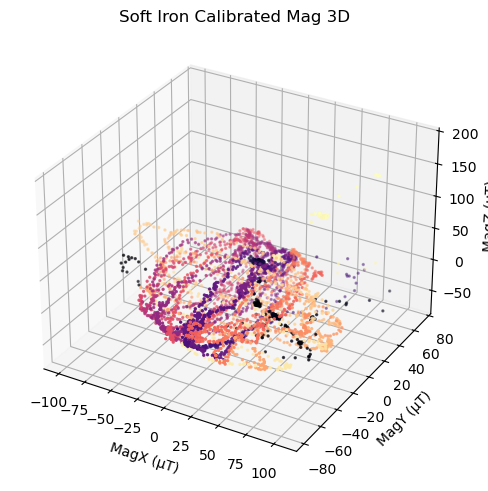

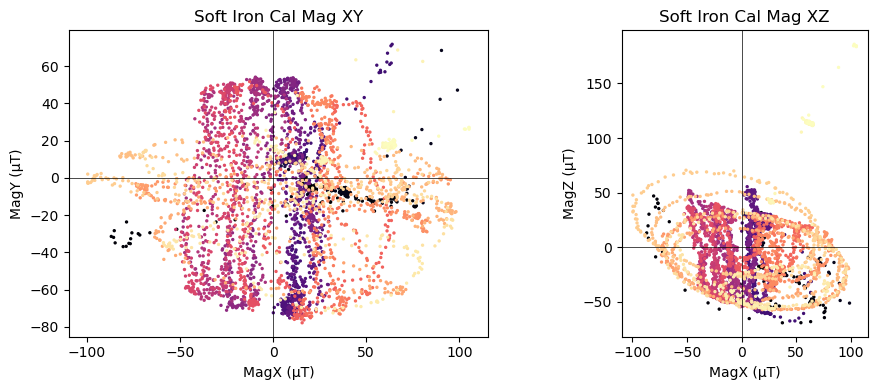

Radius statistics (ideal: low std/mean ratio)
  Hard iron only:       mean=55.155 µT  std=22.630 µT  (std/mean = 0.4103)
  + Soft iron:          mean=56.274 µT  std=21.273 µT  (std/mean = 0.3780)


In [163]:
## Step 9 — Apply the soft iron correction and visualize

# Apply: m_full_cal = W @ (m_raw - hard_iron_offset)
# data_hi is already (m_raw - offset), so just apply W
data_si = (W @ data_hi.T).T

mx_si = data_si[:, 0]
my_si = data_si[:, 1]
mz_si = data_si[:, 2]

# ── 3D scatter ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx_si, my_si, mz_si, s=2, c=t, cmap='magma')
ax3d.set_title('Soft Iron Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)'); ax3d.set_ylabel('MagY (µT)'); ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout(); plt.show()

# ── 2D projections ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx_si, my_si, s=2, c=t, cmap='magma')
axes[0].set_aspect('equal'); axes[0].set_title('Soft Iron Cal Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx_si, mz_si, s=2, c=t, cmap='magma')
axes[1].set_aspect('equal'); axes[1].set_title('Soft Iron Cal Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout(); plt.show()

# ── Radius statistics ────────────────────────────────────────────────────────
data_raw = np.column_stack([mx, my, mz])
r_raw = np.linalg.norm(data_raw, axis=1)
r_hi  = np.linalg.norm(data_hi,  axis=1)
r_si  = np.linalg.norm(data_si,  axis=1)

print('Radius statistics (ideal: low std/mean ratio)')
print(f'  Hard iron only:       mean={r_hi.mean():.3f} µT  std={r_hi.std():.3f} µT  '
      f'(std/mean = {r_hi.std()/r_hi.mean():.4f})')
print(f'  + Soft iron:          mean={r_si.mean():.3f} µT  std={r_si.std():.3f} µT  '
      f'(std/mean = {r_si.std()/r_si.mean():.4f})')